# Figures of chapter 4

In [1]:
from pathlib import Path
import logging
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon

## personal settings
logging.getLogger("fontTools.ttLib.tables._h_e_a_d").setLevel(logging.ERROR)
label = 14
figure_size = (8.0, 4.0)
params = {"text.usetex": False,
          "font.family": "serif",
          "mathtext.fontset": "cm",
          "axes.titlesize": 16,
          "axes.labelsize": label,
          "xtick.labelsize": label,
          "ytick.labelsize": label,
          "figure.facecolor": "w",
          "figure.dpi": 160,
          "savefig.dpi": 160,
          "pdf.fonttype": 42}
plt.rcParams.update(params)
colors = ["#5082FF", "#50AFAF", "#FAA03C", "#B95FF5"]
blue, teal, orange, purple = colors
blur = ((5, .025), (4, .05), (3, .1), (2, .2))

## output folder
working_directory = Path.cwd().resolve()
if working_directory.name == "figures_ch4":
    output_directory = working_directory
elif (working_directory / "figures_ch4").is_dir():
    output_directory = working_directory / "figures_ch4"
else:
    raise RuntimeError("Start this notebook in the thesis root or figures_ch4 folder.")


def glow_curve(ax, x, y, color):
    for linewidth, alpha in blur:
        ax.plot(x, y, lw=linewidth, alpha=alpha, color=color,
                solid_capstyle="round", zorder=3)
    line, = ax.plot(x, y, lw=1.4, alpha=.95, color=color,
                    solid_capstyle="round", zorder=4)
    return line


def save_pdf(fig, name):
    target = output_directory / name
    fig.savefig(target, format="pdf", bbox_inches=None,
                metadata={"Creator": "figures_ch4.ipynb",
                          "CreationDate": None, "ModDate": None})
    plt.show()
    plt.close(fig)

## 4.1 Band subspace

In [2]:
## band dispersions
k = np.linspace(-np.pi, np.pi, 1201)
internal_pair = -.65 - .35 * np.abs(np.cos(k))
models = [(-.60 + .22 * np.cos(k), .60 + .22 * np.cos(k)),
          (-.35 + .80 * np.cos(k), .35 + .80 * np.cos(k)),
          (-.85 * np.sqrt(2 * (1 - np.cos(k))),
            .85 * np.sqrt(2 * (1 - np.cos(k)))),
          (-.65 + .35 * np.abs(np.cos(k)), .65 + .10 * np.cos(k))]

## direct and indirect gaps
fig, axes = plt.subplots(2, 2, figsize=(figure_size[0], 7.0), sharey=True,
                         layout="constrained", dpi=160)
fig.get_layout_engine().set(wspace=.08, hspace=.08, h_pad=.08)
titles = ["(a) Global gap", "(b) Energy overlap", "(c) Boundary contact", "(d) Internal crossing"]
conditions = [r"$\Delta_{\mathrm{dir}}^{\mathrm{min}}>0,\ \Delta_{\mathrm{ind}}>0$",
              r"$\Delta_{\mathrm{dir}}^{\mathrm{min}}>0,\ \Delta_{\mathrm{ind}}<0$",
              r"$\Delta_{\mathrm{dir}}^{\mathrm{min}}=0$",
              r"$\Delta_{\mathrm{dir}}^{\mathrm{min}}>0$"]
for index, (ax, (lower, upper)) in enumerate(zip(axes.flat, models)):
    ax.spines[["right", "top"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(.7)
    ax.set_xlim(-np.pi * 1.06, np.pi * 1.06)
    ax.set_ylim(-1.9, 1.9)
    ax.set_xticks([-np.pi, 0, np.pi], [r"$-\pi$", r"$0$", r"$\pi$"])
    ax.set_yticks([-1, 0, 1])
    ax.tick_params(direction="in", width=.7, labelsize=label)
    fermi_line = ax.axhline(0, color=".40", lw=.8, ls="--", zorder=0)
    ax.set_xlabel(r"$k$", labelpad=4)
    ax.set_title(titles[index] + "\n" + conditions[index],
                 fontsize=16, pad=10, linespacing=1.5)
    lower_line = glow_curve(ax, k, lower, blue)
    upper_line = glow_curve(ax, k, upper, teal)
    if index == 0:
        band_handles = [lower_line, upper_line, fermi_line]
    if index == 3:
        inner_line, = ax.plot(k, internal_pair, color=blue, lw=1.4,
                              ls="--", alpha=.95, zorder=4)
    if index in (0, 1, 3):
        k_same = .35 * np.pi
        low_same = np.interp(k_same, k, lower)
        high_same = np.interp(k_same, k, upper)
        ax.annotate("", (k_same, high_same), (k_same, low_same),
                    arrowprops={"arrowstyle": "<->", "color": orange,
                                "lw": 1.3, "shrinkA": 0, "shrinkB": 0}, zorder=6)
    if index < 2:
        upper_min, lower_max = float(upper.min()), float(lower.max())
        ax.axhline(upper_min, color=purple, lw=.9, ls=":", alpha=.9, zorder=1)
        ax.axhline(lower_max, color=purple, lw=.9, ls=":", alpha=.9, zorder=1)
        if index == 1:
            ax.axhspan(upper_min, lower_max, facecolor=purple, alpha=.055, zorder=-1)
        k_global = -.77 * np.pi
        ax.annotate("", (k_global, upper_min), (k_global, lower_max),
                    arrowprops={"arrowstyle": "<->", "color": purple,
                                "lw": 1.3, "shrinkA": 0, "shrinkB": 0}, zorder=6)
    if index == 2:
        contact = ax.scatter([0], [0], s=60, facecolor="white", edgecolor=orange,
                             linewidth=1.5, zorder=7)
    if index == 3:
        ax.scatter([-np.pi / 2, np.pi / 2], [-.65, -.65], s=60,
                   facecolor="white", edgecolor=orange, linewidth=1.5, zorder=7)
for ax in axes[:, 0]:
    ax.set_ylabel("Energy (arbitrary units)", labelpad=7)

## shared legend
legend_handles = [band_handles[0], inner_line,
                  band_handles[1], band_handles[2],
                  Line2D([], [], color=orange, lw=1.3),
                  Line2D([], [], color=purple, lw=1.3), contact]
legend_labels = [r"$E_{2N_{\mathrm{p}},\vec{k}}$",
                 r"$E_{2N_{\mathrm{p}}-2,\vec{k}}$ (d)",
                 r"$E_{2N_{\mathrm{p}}+1,\vec{k}}$", r"$E_{\mathrm{F}}=0$",
                 r"$\Delta_{\mathrm{dir}}(k)$", r"$\Delta_{\mathrm{ind}}$", "Band contact"]
fig.legend(legend_handles, legend_labels, loc="outside lower center", ncols=4,
           frameon=False, fontsize=label, handlelength=1.8,
           columnspacing=1.2, labelspacing=.6)
save_pdf(fig, "4.1_band_subspace.pdf")


/var/folders/jd/spwt8xjd2jdcbvqz6zhd785m0000gn/T/ipykernel_52009/3643521696.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 4.2 Time-reversal invariant momenta

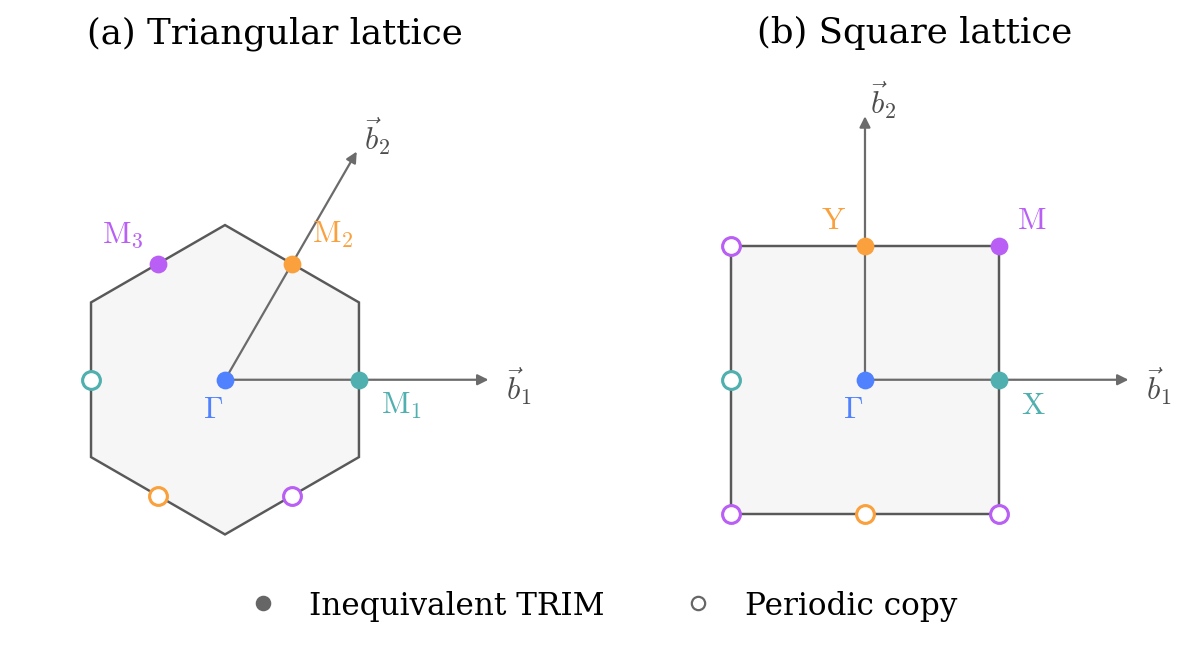

In [3]:
## reciprocal lattices
triangular_basis = np.array([[1., .5], [0., np.sqrt(3) / 2]])
square_basis = np.eye(2)
triangular_points = np.array([[0., 0.], [.5, 0.],
                              [.25, np.sqrt(3) / 4],
                              [-.25, np.sqrt(3) / 4]])
square_points = np.array([[0., 0.], [.5, 0.], [0., .5], [.5, .5]])
triangular_copies = [(1, -triangular_points[1]),
                     (2, -triangular_points[2]),
                     (3, -triangular_points[3])]
square_copies = [(1, np.array([-.5, 0.])), (2, np.array([0., -.5])),
                 (3, np.array([-.5, .5])), (3, np.array([-.5, -.5])),
                 (3, np.array([.5, -.5]))]

## first Brillouin zones
angles = np.deg2rad(30 + 60 * np.arange(6))
hexagon = np.column_stack((np.cos(angles), np.sin(angles))) / np.sqrt(3)
square = np.array([[-.5, -.5], [.5, -.5], [.5, .5], [-.5, .5]])
fig, axes = plt.subplots(1, 2, figsize=figure_size,
                         layout="constrained", dpi=160)
layouts = [
    ("(a) Triangular lattice", triangular_basis, hexagon,
     triangular_points, triangular_copies,
     [r"$\Gamma$", r"$\mathrm{M}_1$", r"$\mathrm{M}_2$", r"$\mathrm{M}_3$"],
     [(-10, -17), (10, -15), (9, 10), (-25, 10)]),
    ("(b) Square lattice", square_basis, square,
     square_points, square_copies,
     [r"$\Gamma$", r"$\mathrm{X}$", r"$\mathrm{Y}$", r"$\mathrm{M}$"],
     [(-10, -17), (10, -15), (-20, 8), (8, 8)])]
for ax, (title, basis, polygon, points, copies, names, offsets) in zip(axes, layouts):
    ax.set_aspect("equal")
    ax.set_xlim(-.78, 1.15)
    ax.set_ylim(-.72, 1.16)
    ax.set_axis_off()
    ax.set_title(title, fontsize=16, loc="center", pad=12)
    ax.add_patch(Polygon(polygon, closed=True, facecolor=".965",
                         edgecolor=".35", linewidth=1.1, zorder=0))
    for j in range(2):
        vector = basis[:, j]
        ax.annotate("", xy=vector, xytext=(0, 0),
                    arrowprops={"arrowstyle": "-|>", "color": ".42", "lw": 1.0}, zorder=1)
        shift = np.array([.05, -.02]) if j == 0 else np.array([.02, .045])
        ax.text(*(vector + shift), rf"$\vec{{b}}_{j+1}$", fontsize=label,
                va="center", ha="left", color=".30")
    for original, point in copies:
        ax.scatter(*point, s=64, facecolors="white", edgecolors=colors[original],
                   linewidths=1.4, zorder=4)
    for point, color, name, offset in zip(points, colors, names, offsets):
        ax.scatter(*point, s=64, c=color, linewidths=0, zorder=5)
        ax.annotate(name, xy=point, xytext=offset, textcoords="offset points",
                    fontsize=label, color=color, zorder=6)

legend_handles = [Line2D([], [], marker="o", linestyle="None", color=".4",
                          markerfacecolor=".4", markersize=6,
                          label="Inequivalent TRIM"),
                  Line2D([], [], marker="o", linestyle="None", color=".4",
                          markerfacecolor="white", markersize=6,
                          label="Periodic copy")]
fig.legend(handles=legend_handles, loc="outside lower center", ncols=2,
           frameon=False, fontsize=label, handletextpad=.5, columnspacing=2.0)
save_pdf(fig, "4.2_trim.pdf")